# 11. Spectrum Occupancy Trend Prediction using SSA and SVR

This notebook implements the **SSA-SVR** trend prediction method from the paper:
"A Trend Prediction Method for Failures Time Series Data by Exploring Singular Spectrum Analysis and Support Vector Machines Regression" (ICCSNT 2019).

**Pipeline:**
1. **SSA** (Singular Spectrum Analysis) — extract **trend** from the raw AU series; **residual** = raw − trend.
2. **SVR** (Support Vector Regression) — train one SVR on (window → next value) for **trend**, one for **residual**; multi-step forecast by iteration.
3. **AU prediction** = predicted trend + predicted residual (clipped to 0–100%).

**Same setup as notebook 10:** Same data (`work_dir/final`), same next-day prediction (last 72h → next 24h), same metrics (MAE, RMSE, MASE) on **raw AU**.

**Environment:** Use kernel **Python 3.11 (cablelabs-3 .venv)** (Kernel → Change kernel) for the same environment as notebook 10. SVR runs on CPU; this kernel ensures consistent dependencies.

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print('Imports OK')

Imports OK


In [22]:
# CPU/GPU: same venv as notebook 10; SVR runs on CPU
import os
NUM_CORES = os.cpu_count() or 4
try:
    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f'GPU: {len(gpus)} device(s) available (TensorFlow). SVR uses CPU.')
    else:
        print(f'Using up to {NUM_CORES} CPU cores (no GPU detected)')
except Exception:
    print(f'Using up to {NUM_CORES} CPU cores')

GPU: 1 device(s) available (TensorFlow). SVR uses CPU.


### Predict next day

- **Training:** 6 days. We use the **last 3 days (72 h)** as input and the **next 24 h (next day)** as target.
- **Testing:** 3 days — one sample per test day; input = previous 72 h, target = that day's 24 h.
- **Parameters:** `LOOKBACK = 72`, `FORECAST_HORIZON = 24`.

In [23]:
work_dir = Path("work_dir")
if not work_dir.exists():
    work_dir = Path("../work_dir")
final_dir = work_dir / "final"
if not final_dir.exists():
    raise FileNotFoundError('Final dir not found: ' + str(final_dir))

training_dir = final_dir / "training"
testing_dir = final_dir / "testing"
if not training_dir.exists() or not testing_dir.exists():
    raise FileNotFoundError('Training or testing directory not found')

classes_found = [d.name for d in sorted(training_dir.iterdir()) if d.is_dir()]
class_options = sorted(set(classes_found))
print(f'Found {len(class_options)} classes (bands): {class_options}')

Found 6 classes (bands): ['195MHz', '2441MHz', '3765MHz', '539MHz', '5500MHz', '915MHz']


## Data loading and preparation

In [24]:
def load_data_for_band(band_name: str, split: str = "training"):
    split_dir = final_dir / split / band_name
    if not split_dir.exists():
        return pd.DataFrame()
    dfs = []
    for p in sorted(split_dir.glob("final_*.parquet")):
        try:
            dfs.append(pd.read_parquet(p))
        except Exception as e:
            print(f'Error loading {p}: {e}')
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def get_series_per_freq(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """Return dict freq -> (train_series, test_series) for SSA-SVR."""
    thresholds = sorted(train_df["threshold_dbm"].unique())
    if len(thresholds) > 1:
        train_df = train_df[train_df["threshold_dbm"] == thresholds[0]].copy()
        test_df = test_df[test_df["threshold_dbm"] == thresholds[0]].copy()
    out = {}
    for freq in sorted(train_df["freq_center_ghz"].unique()):
        tr = train_df[train_df["freq_center_ghz"] == freq].sort_values(["date", "hour"])["au_pct"].values
        te = test_df[test_df["freq_center_ghz"] == freq].sort_values(["date", "hour"])["au_pct"].values
        if len(tr) > 0 and len(te) > 0:
            out[freq] = (tr, te)
    return out

In [25]:
LOOKBACK = 72
FORECAST_HORIZON = 24

train_data_by_band = {}
test_data_by_band = {}
for band in class_options:
    train_df = load_data_for_band(band, "training")
    test_df = load_data_for_band(band, "testing")
    if not train_df.empty and not test_df.empty:
        train_data_by_band[band] = train_df
        test_data_by_band[band] = test_df
        print(f'Band {band}: Train={len(train_df)} rows, Test={len(test_df)} rows')
print(f'\nLoaded {len(train_data_by_band)} bands')

Band 195MHz: Train=12096 rows, Test=6048 rows
Band 2441MHz: Train=12240 rows, Test=6120 rows
Band 3765MHz: Train=11664 rows, Test=5832 rows
Band 539MHz: Train=19008 rows, Test=9504 rows
Band 5500MHz: Train=20304 rows, Test=10152 rows
Band 915MHz: Train=15264 rows, Test=7632 rows

Loaded 6 bands


## Model reference (paper)

| Paper | This notebook |
|-------|----------------|
| **SSA:** window L, SVD, first r components, diagonal averaging | `ssa_trend(series, L, r)` |
| **SVR:** RBF kernel, C, ε, γ; window L_SVR → next value | `SVR(kernel='rbf')` on (window → 1 step); multi-step by iteration |
| Grid search over L_SSA, L_SVR, ε (min RMSE) | Single parameter set; grid search optional |
| Metrics: RMSE, MAE | MAE, RMSE, MASE (same as notebook 10) |

## SSA (Singular Spectrum Analysis)

Paper: embedding with window length L, SVD, group first r components, diagonal averaging to get trend series.

In [26]:
def ssa_trend(series: np.ndarray, L: int, r: int = 1):
    """
    Extract trend via SSA: embed -> SVD -> reconstruct from first r components -> diagonal averaging.
    L = window length, r = number of components (small r = smoother trend).
    """
    n = len(series)
    if n < L or L < 2 or r < 1:
        return series.copy()
    K = n - L + 1
    # Trajectory matrix (L x K)
    X = np.column_stack([series[i:i+L] for i in range(K)])
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    # Reconstruct from first r components
    Xr = (U[:, :r] * s[:r]) @ Vt[:r, :]
    # Diagonal averaging -> time series
    trend = np.zeros(n)
    for k in range(n):
        i_lo, i_hi = max(0, k - K + 1), min(k, L - 1)
        if i_lo <= i_hi:
            trend[k] = np.mean([Xr[i, k - i] for i in range(i_lo, i_hi + 1)])
    return trend

## SVR prediction (trend + residual → AU)

Train one SVR on (window of trend → next trend) and one on (window of residual → next residual). Multi-step: predict 24h trend and 24h residual iteratively; **AU prediction = trend_pred + residual_pred** (clipped to 0–100%).

In [27]:
def build_svr_xy(trend: np.ndarray, L_svr: int):
    """Build (X, y) for SVR: each row = L_svr values, target = next value."""
    X, y = [], []
    for i in range(len(trend) - L_svr):
        X.append(trend[i:i+L_svr])
        y.append(trend[i+L_svr])
    return np.array(X), np.array(y)


def predict_multistep(svr, scaler_x, scaler_y, last_window: np.ndarray, steps: int, clip_bounds=(0, 100)):
    """Predict next `steps` values iteratively. Window in original scale. clip_bounds for inverse scale."""
    preds = []
    w = last_window.copy().astype(float)
    for _ in range(steps):
        x = scaler_x.transform(w.reshape(1, -1))
        p_scaled = svr.predict(x)[0]
        p_scaled = np.clip(p_scaled, 0, 1)
        p_orig = float(scaler_y.inverse_transform([[p_scaled]])[0, 0])
        p_orig = np.clip(p_orig, clip_bounds[0], clip_bounds[1])
        preds.append(p_orig)
        w = np.roll(w, -1)
        w[-1] = p_orig
    return np.array(preds)


def fit_svr_and_predict_per_freq(train_series: np.ndarray, test_series: np.ndarray,
                                  L_ssa: int, r_ssa: int, L_svr: int,
                                  C: float, epsilon: float, gamma: float,
                                  forecast_horizon: int, n_test_days: int):
    """SSA trend+residual; train SVR on trend and SVR on residual; predict AU = trend_pred + residual_pred."""
    full = np.concatenate([train_series, test_series])
    trend_full = ssa_trend(full, L_ssa, r_ssa)
    residual_full = full - trend_full
    n_train = len(train_series)
    trend_train = trend_full[:n_train]
    residual_train = residual_full[:n_train]
    if len(trend_train) < L_svr + 1 or len(test_series) < n_test_days * forecast_horizon:
        return None, None
    # SVR for trend
    X_tr_t, y_tr_t = build_svr_xy(trend_train, L_svr)
    scaler_x_t = MinMaxScaler(feature_range=(0, 1))
    scaler_y_t = MinMaxScaler(feature_range=(0, 1))
    X_tr_t_s = scaler_x_t.fit_transform(X_tr_t)
    y_tr_t_s = scaler_y_t.fit_transform(y_tr_t.reshape(-1, 1)).ravel()
    svr_trend = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
    svr_trend.fit(X_tr_t_s, y_tr_t_s)
    # SVR for residual
    X_tr_r, y_tr_r = build_svr_xy(residual_train, L_svr)
    scaler_x_r = MinMaxScaler(feature_range=(0, 1))
    scaler_y_r = MinMaxScaler(feature_range=(0, 1))
    X_tr_r_s = scaler_x_r.fit_transform(X_tr_r)
    y_tr_r_s = scaler_y_r.fit_transform(y_tr_r.reshape(-1, 1)).ravel()
    svr_residual = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
    svr_residual.fit(X_tr_r_s, y_tr_r_s)
    res_min, res_max = float(residual_train.min()), float(residual_train.max())
    res_range = max(res_max - res_min, 1e-6)
    clip_residual = (res_min - 0.1 * res_range, res_max + 0.1 * res_range)
    preds_per_day = []
    trend_hist = list(trend_train)
    residual_hist = list(residual_train)
    for d in range(n_test_days):
        pred_trend_24 = predict_multistep(svr_trend, scaler_x_t, scaler_y_t, np.array(trend_hist[-L_svr:]), forecast_horizon, clip_bounds=(0, 100))
        pred_residual_24 = predict_multistep(svr_residual, scaler_x_r, scaler_y_r, np.array(residual_hist[-L_svr:]), forecast_horizon, clip_bounds=clip_residual)
        au_24 = np.clip(pred_trend_24 + pred_residual_24, 0, 100)
        preds_per_day.append(au_24)
        trend_hist.extend(pred_trend_24)
        residual_hist.extend(pred_residual_24)
    y_pred_au = np.array(preds_per_day)
    y_true_au = test_series[:n_test_days * forecast_horizon].reshape(n_test_days, forecast_horizon)
    return y_pred_au, y_true_au

In [28]:
def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true.flatten(), y_pred.flatten())

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))

def calculate_mase(y_true, y_pred, y_train):
    mae = np.mean(np.abs(y_true.flatten() - y_pred.flatten()))
    if len(y_train) > 1:
        scale = np.mean(np.abs(np.diff(y_train.flatten()))) or 1.0
    else:
        scale = 1.0
    return mae / scale

## SSA-SVR parameters and training

Paper: L_SSA (window SSA), L_SVR (window SVR), ε (epsilon), C and γ (gamma). We use one reasonable set; optional grid search can be added.

In [29]:
L_SSA = 8
r_SSA = 1
L_SVR = 24
C_SVR = 3.0
epsilon_SVR = 0.05
gamma_SVR = 'scale'

n_test_days = 3
all_y_pred, all_y_true = [], []
all_y_train = []

for band in class_options:
    if band not in train_data_by_band:
        continue
    train_df = train_data_by_band[band]
    test_df = test_data_by_band[band]
    series_per_freq = get_series_per_freq(train_df, test_df)
    for freq, (tr, te) in series_per_freq.items():
        res = fit_svr_and_predict_per_freq(tr, te, L_SSA, r_SSA, L_SVR,
                                            C_SVR, epsilon_SVR, gamma_SVR,
                                            FORECAST_HORIZON, n_test_days)
        if res[0] is not None:
            y_pred, y_true = res
            all_y_pred.append(y_pred)
            all_y_true.append(y_true)
            all_y_train.append(tr)

if not all_y_pred:
    raise ValueError('No predictions; check data and parameters.')

y_pred_ssa_svr = np.vstack(all_y_pred)
y_test_au = np.vstack(all_y_true)
y_train_au = np.concatenate(all_y_train)
print(f'SSA-SVR (AU) predictions shape: {y_pred_ssa_svr.shape}')
print(f'Test AU shape: {y_test_au.shape}')

SSA-SVR (AU) predictions shape: (1887, 24)
Test AU shape: (1887, 24)


In [30]:
mae_ssa_svr = calculate_mae(y_test_au, y_pred_ssa_svr)
rmse_ssa_svr = calculate_rmse(y_test_au, y_pred_ssa_svr)
mase_ssa_svr = calculate_mase(y_test_au, y_pred_ssa_svr, y_train_au)

results = [{'Model': 'SSA-SVR', 'MAE': mae_ssa_svr, 'RMSE': rmse_ssa_svr, 'MASE': mase_ssa_svr}]
results_df = pd.DataFrame(results)
results_df['MAE'] = results_df['MAE'].round(4)
results_df['RMSE'] = results_df['RMSE'].round(4)
results_df['MASE'] = results_df['MASE'].round(4)
print('\n' + '='*60)
print('RESULTS (AU prediction; metrics on raw AU)')
print('='*60)
print(f'Lookback: {LOOKBACK}h, Forecast: {FORECAST_HORIZON}h')
print(results_df.to_string(index=False))
print(f'\nSummary: MAE = {mae_ssa_svr:.4f}, RMSE = {rmse_ssa_svr:.4f}, MASE = {mase_ssa_svr:.4f}')
display(results_df)


RESULTS (AU prediction; metrics on raw AU)
Lookback: 72h, Forecast: 24h
  Model    MAE  RMSE   MASE
SSA-SVR 4.9239 9.818 2.4552


,Model,MAE,RMSE,MASE
0,SSA-SVR,4.9239,9.818,2.4552


## Predicted vs actual (dashed)

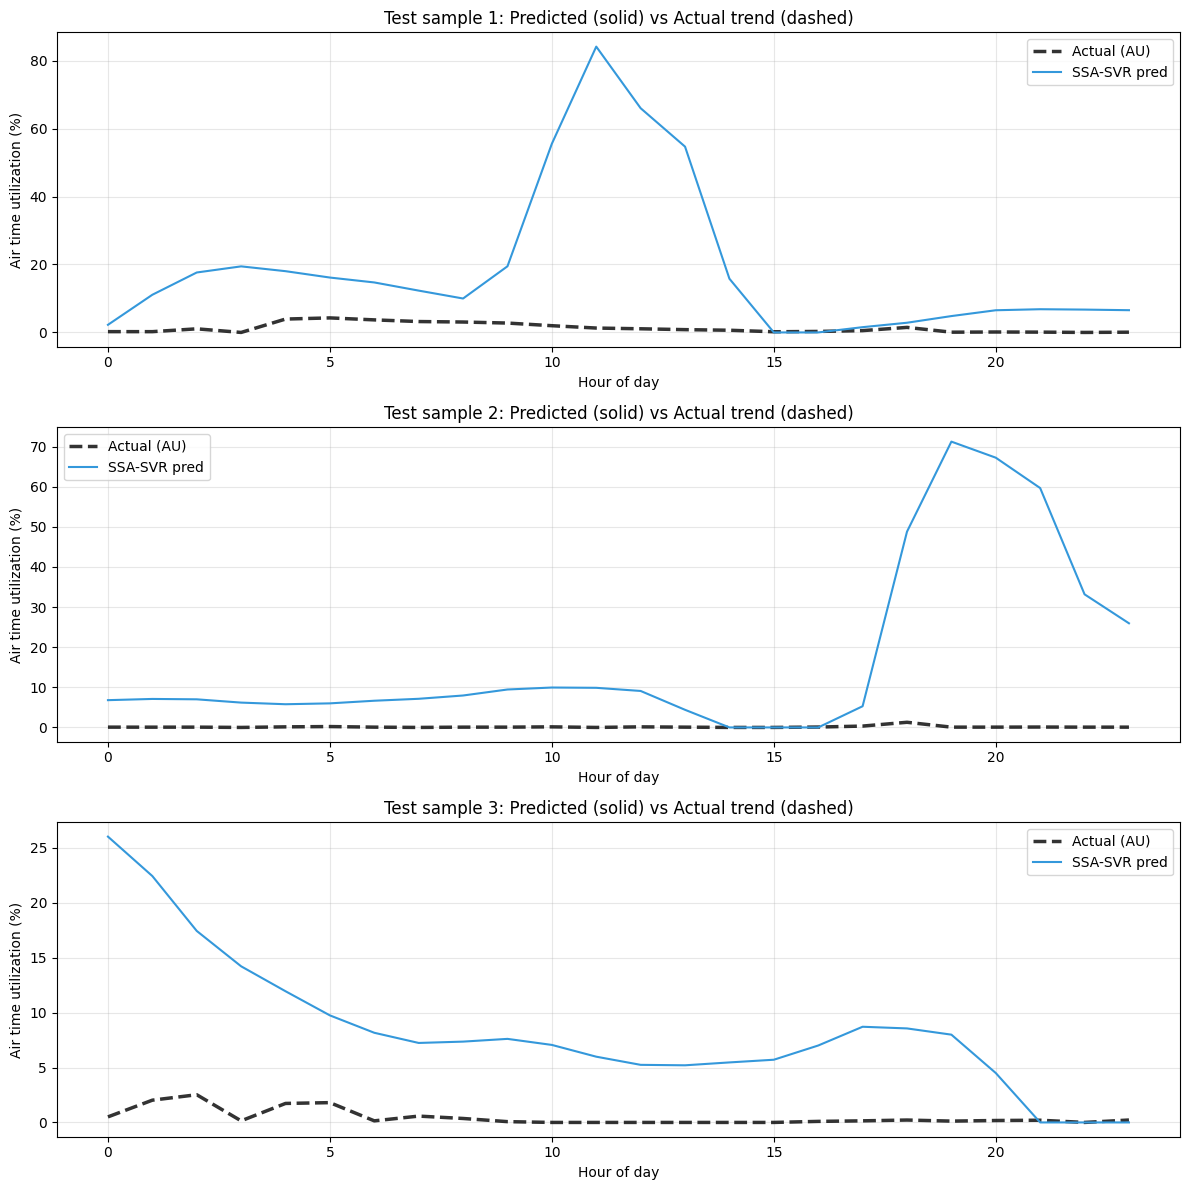

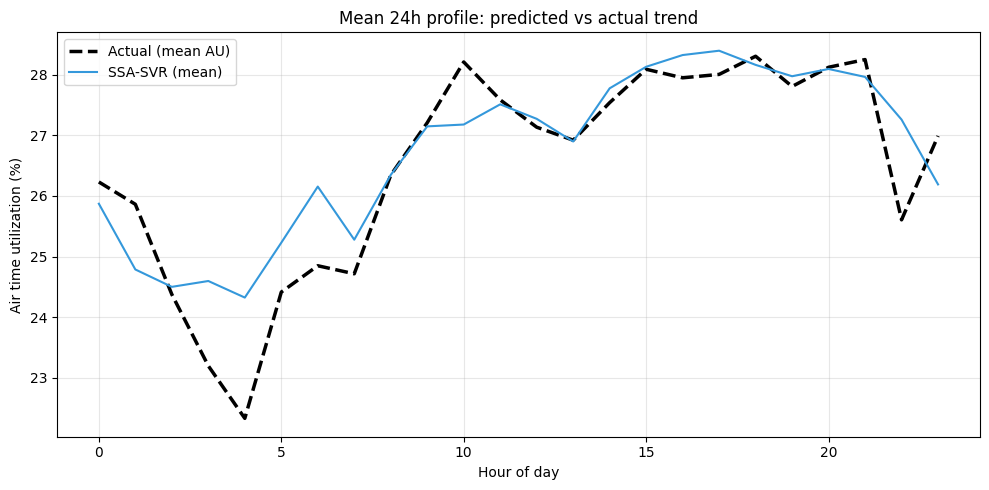

In [31]:
hours = np.arange(FORECAST_HORIZON)
n_show = min(3, len(y_pred_ssa_svr))
fig, axes = plt.subplots(n_show, 1, figsize=(12, 4*n_show))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    ax = axes[i]
    ax.plot(hours, y_test_au[i], 'k--', linewidth=2.5, label='Actual (AU)', alpha=0.8)
    ax.plot(hours, y_pred_ssa_svr[i], '-', color='#3498db', linewidth=1.5, label='SSA-SVR pred')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Air time utilization (%)')
    ax.set_title(f'Test sample {i+1}: Predicted (solid) vs Actual trend (dashed)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hours, y_test_au.mean(axis=0), 'k--', linewidth=2.5, label='Actual (mean AU)')
ax.plot(hours, y_pred_ssa_svr.mean(axis=0), '-', color='#3498db', linewidth=1.5, label='SSA-SVR (mean)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Air time utilization (%)')
ax.set_title('Mean 24h profile: predicted vs actual trend')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()